In [1]:
import numpy as np

from bootstrap_diagnostics import DoubleBootstrap, IIDResampler

In [3]:
rng = np.random.default_rng(123)

In [10]:
X = np.array([[1, 2], [3, 4], [5, 6]])
resampler = IIDResampler(X, axis=-1)
resampler.draw_sample(rng)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [19]:
rng = np.random.default_rng(123)

mean = 1.0
sample_size = 20
n_covers = 0
n_iterations = 500
seed = 42
confidence_level = 0.95

# for i in range(n_iterations):
sample = rng.exponential(scale=mean, size=sample_size)


def mean(x):
    return np.mean(x)


resampler = IIDResampler(sample)
db = DoubleBootstrap(statistic=mean, resampler=resampler)
ci = db.confidence_interval(confidence_level, seed=seed, side="two", n_jobs=-1)

# if ci.lower <= mean <= ci.upper:
# n_covers += 1

# print(f"Final coverage: {n_covers / n_iterations}")
print(ci)

lower = 0.48925326639695677
upper = 1.6712732012214104
confidence level = 0.95, side = two


In [14]:
ci = db.confidence_interval(confidence_level, seed=seed, side="two", n_jobs=4)
print(ci)

lower = 0.48925326639695677
upper = 1.6712732012214104
confidence level = 0.95, side = two


In [20]:
rng = np.random.default_rng(123)

true_corr = 0.5
mu = [1, 1]
cov_matrix = [
    [1.0, true_corr],
    [true_corr, 1.0],
]


def pearsonr(x):
    return np.corrcoef(x, rowvar=False)[0, 1]


n_covers = 0
n_iterations = 250
for i in range(n_iterations):
    data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=20)
    sampler = IIDResampler(data, axis=0)

    db = DoubleBootstrap(pearsonr, sampler)

    ci = db.confidence_interval(confidence_level, seed=seed, n_jobs=-1)

    if ci.lower <= true_corr <= ci.upper:
        n_covers += 1
    # print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

print(f"Final coverage: {n_covers / n_iterations}")

Final coverage: 0.956


In [21]:
n_samples = 300
beta_gt = np.array([1.5, -0.5])

rng = np.random.default_rng(123)

# Design matrix
X = rng.normal(scale=3, size=(n_samples, 2))
X[:, 0] = 1.0

y = X @ beta_gt
y_noise = y + rng.normal(0, 2, n_samples)

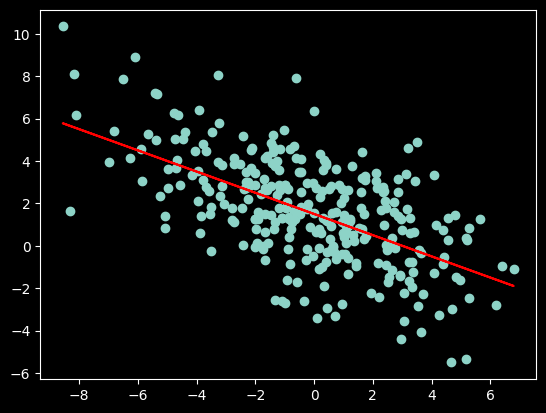

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 1], y_noise)
plt.plot(X[:, 1], y, color="red")

In [23]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef

In [24]:
dataset = np.hstack([X, y_noise[:, np.newaxis]])
dataset[:3, :]

array([[ 1.        , -1.10335995, -2.62318714],
       [ 1.        ,  0.58192326,  2.82600659],
       [ 1.        ,  1.73131137,  3.10115388]])

In [25]:
res = regression_coeffs(dataset)
res

array([ 1.57545378, -0.50689414])

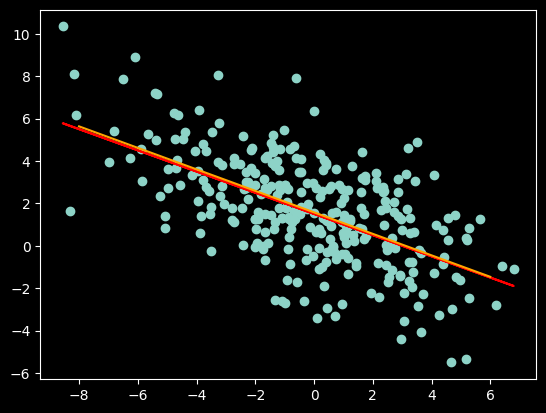

In [26]:
plt.scatter(X[:, 1], y_noise)

test = np.array([[1, -8], [1, 6]])
plt.plot(X[:, 1], y, color="red")
plt.plot(test[:, 1], test @ res, color="orange")

In [27]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)

ci = db.confidence_interval(confidence_level, seed=42, side="two", n_jobs=-1)


In [28]:
print(ci)

lower = [ 1.32731596 -0.59917996]
upper = [ 1.80754835 -0.42036916]
confidence level = 0.95, side = two


In [29]:
# Mean over the axis 0
rng = np.random.default_rng(123)

dataset = rng.normal(4, 3, size=(1000, 5, 5))


def mean_mat(x):
    return np.mean(x, axis=0)


print(mean_mat(dataset))


[[3.97415827 4.05517178 3.98702731 3.8743683  4.053281  ]
 [3.85367802 4.04472862 3.90890697 3.97792991 4.09252102]
 [4.12935094 4.01554232 4.01457519 3.94975741 4.0721076 ]
 [4.142231   4.13575172 4.03679546 3.93236058 4.007144  ]
 [4.14654217 4.07239243 3.87138847 4.03090362 3.89220331]]


In [30]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=mean_mat, resampler=resampler)
ci = db.confidence_interval(0.95, n_jobs=-1)
print(ci)

lower = [[3.78695839 3.85675763 3.80212589 3.69844363 3.86628941]
 [3.66877579 3.85820255 3.71828472 3.81403068 3.89872597]
 [3.95006677 3.82857061 3.82656629 3.76302558 3.89130106]
 [3.94744177 3.94766352 3.84003018 3.74314542 3.8254276 ]
 [3.9305863  3.88326485 3.69377821 3.84357084 3.70564606]]
upper = [[4.16924765 4.25477149 4.16260348 4.04200028 4.22636448]
 [4.0508867  4.24737513 4.10085002 4.14473135 4.28793153]
 [4.31691611 4.19825635 4.19441322 4.13093642 4.25260602]
 [4.33240588 4.33143665 4.2350727  4.11633387 4.19480825]
 [4.36130117 4.25148031 4.0556996  4.22765341 4.0884297 ]]
confidence level = 0.95, side = two


In [31]:
import pandas as pd

rng = np.random.default_rng(123)

beta_gt = np.array([1, -0.5, -3, 2, 1.5])

dataset = pd.DataFrame(
    rng.normal(4, 3, size=(100, 5)),
    columns=[f"x{i}" for i in range(5)],
)
dataset["x0"] = 1.0
dataset["y"] = dataset.values @ beta_gt + rng.normal(0, 2, size=100)

dataset.head()

,x0,x1,x2,x3,x4,y
0,1.0,2.896640,7.863776,4.581923,6.760693,-9.465066
1,1.0,2.090609,5.625857,3.050214,3.032833,-5.764266
2,1.0,-0.577791,7.576498,1.986731,7.000808,-5.489898
3,1.0,8.596099,2.020092,3.064615,5.013307,6.230820
4,1.0,6.483764,8.624891,7.380420,6.264309,-0.841128


In [32]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef


resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)
ci = db.confidence_interval(0.95, seed=42, n_jobs=-1)
print(ci)

lower = [-0.20527564 -0.5674204  -3.14673549  1.93613784  1.27923942]
upper = [ 1.89266133 -0.27957173 -2.88097537  2.23219435  1.54995299]
confidence level = 0.95, side = two


In [33]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)

ci = db.confidence_interval(0.95, seed=42, side="two", n_jobs=-1)
print(ci)

lower = [-0.20527564 -0.5674204  -3.14673549  1.93613784  1.27923942]
upper = [ 1.89266133 -0.27957173 -2.88097537  2.23219435  1.54995299]
confidence level = 0.95, side = two


In [39]:
dataset_t = dataset.values.T


def regression_coeffs_t(data):
    x = data[:-1, :].T
    y = data[-1, :].T
    return np.linalg.lstsq(x, y, rcond=None)[0]


# Try out different data dimension
resampler = IIDResampler(dataset_t, axis=1)
ci = db.confidence_interval(0.95, seed=42, side="two", n_jobs=3)
print(ci)

lower = [-0.20527564 -0.5674204  -3.14673549  1.93613784  1.27923942]
upper = [ 1.89266133 -0.27957173 -2.88097537  2.23219435  1.54995299]
confidence level = 0.95, side = two
